<a href="https://colab.research.google.com/github/anitinfo16-dot/INTERNSHIP-PROJECTS/blob/main/CIFAR_10_CNN_ACCURACY_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import tensorflow as tf
from  tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import numpy as np

**LOAD CIFAR-10 DATASET**

In [2]:
(x_test,y_test),(x_train,y_train)=tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 458s 3us/step


In [3]:
num_classes= len(np.unique(y_train))
print('Number of classes:',num_classes)
print('Class labels:',np.unique(y_train))

Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


PRINT SHAPES

In [4]:
x_train.shape

(10000, 32, 32, 3)

In [5]:
y_train.shape

(10000, 1)

In [6]:

x_test.shape

(50000, 32, 32, 3)

In [7]:
y_test.shape

(50000, 1)

SHAPE OF A SINGLE IMAGE

In [8]:
print('Shape of a single image(x_train[0]):',x_train[0].shape)

Shape of a single image(x_train[0]): (32, 32, 3)


NORMALIZATION

In [9]:
x_train,x_test=x_train/255.0,x_test/255.0

FLATTEN LABEL

In [10]:
y_train=y_train.flatten()
y_test=y_test.flatten()

CLASS NAMES

In [11]:
class_names = [str(i) for i in range(10)]

PLOT A SAMPLE IMAGE

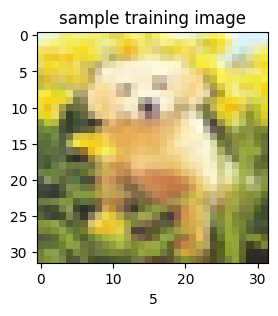

In [12]:
def plot_sample(x,y,index):
  plt.figure(figsize=(3,3))
  plt.imshow(x[index])
  plt.xlabel(class_names[y[index]])
  plt.title('sample training image')
  plt.show()
plot_sample(x_train,y_train,190)

BUILD CNN MODELS

In [13]:
model = tf.keras.models.Sequential([
    layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,778 (1.54 MB)

 Trainable params: 403,882 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

TRAIN THE MODEL

In [15]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(x_train,y_train,epochs=30,validation_data=(x_test,y_test),batch_size=64)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 146s 901ms/step - accuracy: 0.3101 - loss: 2.2171 - val_accuracy: 0.1003 - val_loss: 3.6538
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 139s 888ms/step - accuracy: 0.4356 - loss: 1.6182 - val_accuracy: 0.2309 - val_loss: 2.5250
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 137s 877ms/step - accuracy: 0.5022 - loss: 1.3922 - val_accuracy: 0.3104 - val_loss: 2.0694
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 137s 873ms/step - accuracy: 0.5577 - loss: 1.2519 - val_accuracy: 0.4501 - val_loss: 1.6807
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 137s 876ms/step - accuracy: 0.5910 - loss: 1.1473 - val_accuracy: 0.6053 - val_loss: 1.1160
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 148s 945ms/step - accuracy: 0.6263 - loss: 1.0595 - val_accuracy: 0.6209 - val_loss: 1.0813
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 147s 941ms/step - accuracy: 0.6523 - loss: 0.9914 - val_accuracy: 0.6317 - val_loss: 1.0656
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 137s 873ms/step - accuracy: 0.6688 -

In [16]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print('Test Accuracy:',test_accuracy)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.7368 - loss: 0.8592
Test Accuracy: 0.7368000149726868


PLOT ACCURACY & LOSE

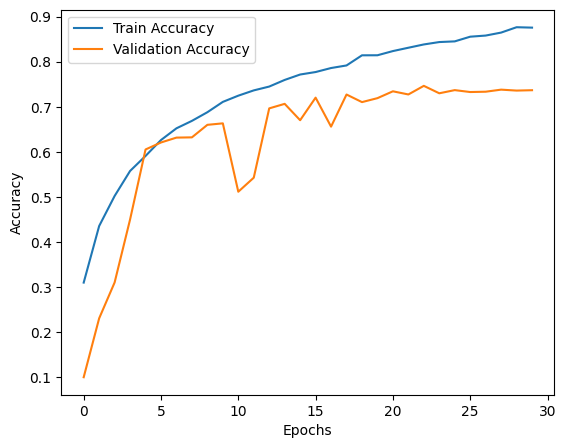

In [17]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

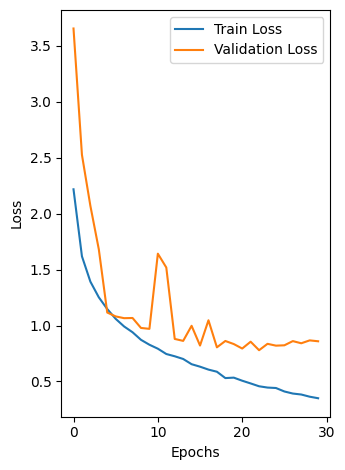

In [18]:
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

PREDICT ON TEST SET

In [19]:
y_pred_probs=model.predict(x_test)
y_pred_classes=np.argmax(y_pred_probs,axis=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step


CONFUSION MATRIX

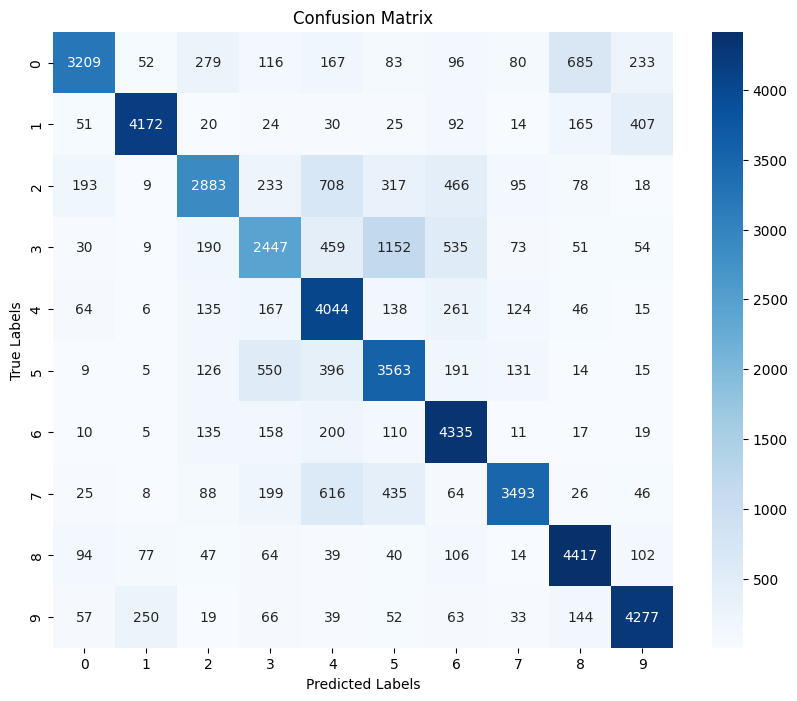

In [20]:
cm=confusion_matrix(y_test,y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True,fmt='d',cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

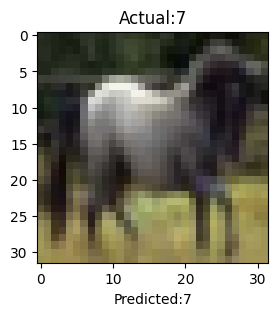

In [21]:
index=1997
plt.figure(figsize=(3,3))
plt.imshow(x_test[index])
plt.title(f'Actual:{class_names[y_test[index]]}')
plt.xlabel(f'Predicted:{class_names[y_pred_classes[index]]}')
plt.show()
